<a href="https://colab.research.google.com/github/Solmaeir/Roman_Columns/blob/main/Roman_Columns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Klasör yollarını tanımla
BASE = '/content/drive/MyDrive/sutun_veriseti_1'
DAMAGED_DIR   = os.path.join(BASE, 'damaged_column')
REFERENCE_DIR = os.path.join(BASE, 'referance_column')

# Kontrol
damaged_files   = [f for f in os.listdir(DAMAGED_DIR)   if f.lower().endswith(('.jpg','.jpeg','.png'))]
reference_files = [f for f in os.listdir(REFERENCE_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]

print(f"Damaged:   {len(damaged_files)} görüntü")
print(f"Reference: {len(reference_files)} görüntü")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Damaged:   30 görüntü
Reference: 68 görüntü


In [2]:
!pip install segment-anything -q
!pip install pillow==9.5.0 -q  # SAM ile uyumlu sürüm
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# Kurulumdan sonra runtime'ı yeniden başlat
import importlib, PIL
importlib.reload(PIL)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 26.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.


<module 'PIL' from '/usr/local/lib/python3.12/dist-packages/PIL/__init__.py'>

In [1]:
# Kurulum kontrolü
import torch
from segment_anything import sam_model_registry
from PIL import Image
import cv2
import numpy as np

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("PIL:", Image.__version__)
print("OpenCV:", cv2.__version__)
print("Tümü OK — devam edebilirsin")

Torch: 2.10.0+cpu
CUDA: False
PIL: 9.5.0
OpenCV: 4.13.0
Tümü OK — devam edebilirsin


In [2]:
!pip install segment-anything -q
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import torch

In [7]:
# Model yükle (vit_b = hızlı, yeterince iyi)
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    min_mask_region_area=500,   # küçük gürültüleri ele
)

def get_column_mask_sam(img_bgr):
    """
    SAM ile en büyük nesneyi (kolon) bul,
    onun dışını ve iç boşluklarını hasar maskesi yap.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    masks   = mask_generator.generate(img_rgb)

    if not masks:
        print("Hiç maske bulunamadı.")
        return None, None

    # En büyük alanı kaplayan segment = kolon gövdesi
    masks_sorted = sorted(masks, key=lambda m: m['area'], reverse=True)
    column_mask  = masks_sorted[0]['segmentation'].astype(np.uint8) * 255

    # Kolon içindeki delikleri/boşlukları doldur
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    column_filled = cv2.morphologyEx(column_mask, cv2.MORPH_CLOSE, kernel, iterations=4)

    # Hasar = dolu alan - mevcut alan (yani kolon içindeki boşluklar)
    damage_mask = cv2.bitwise_and(column_filled, cv2.bitwise_not(column_mask))

    # Küçük gürültü temizle
    damage_mask = cv2.morphologyEx(damage_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return column_mask, damage_mask

Bulunan segment sayısı: 26


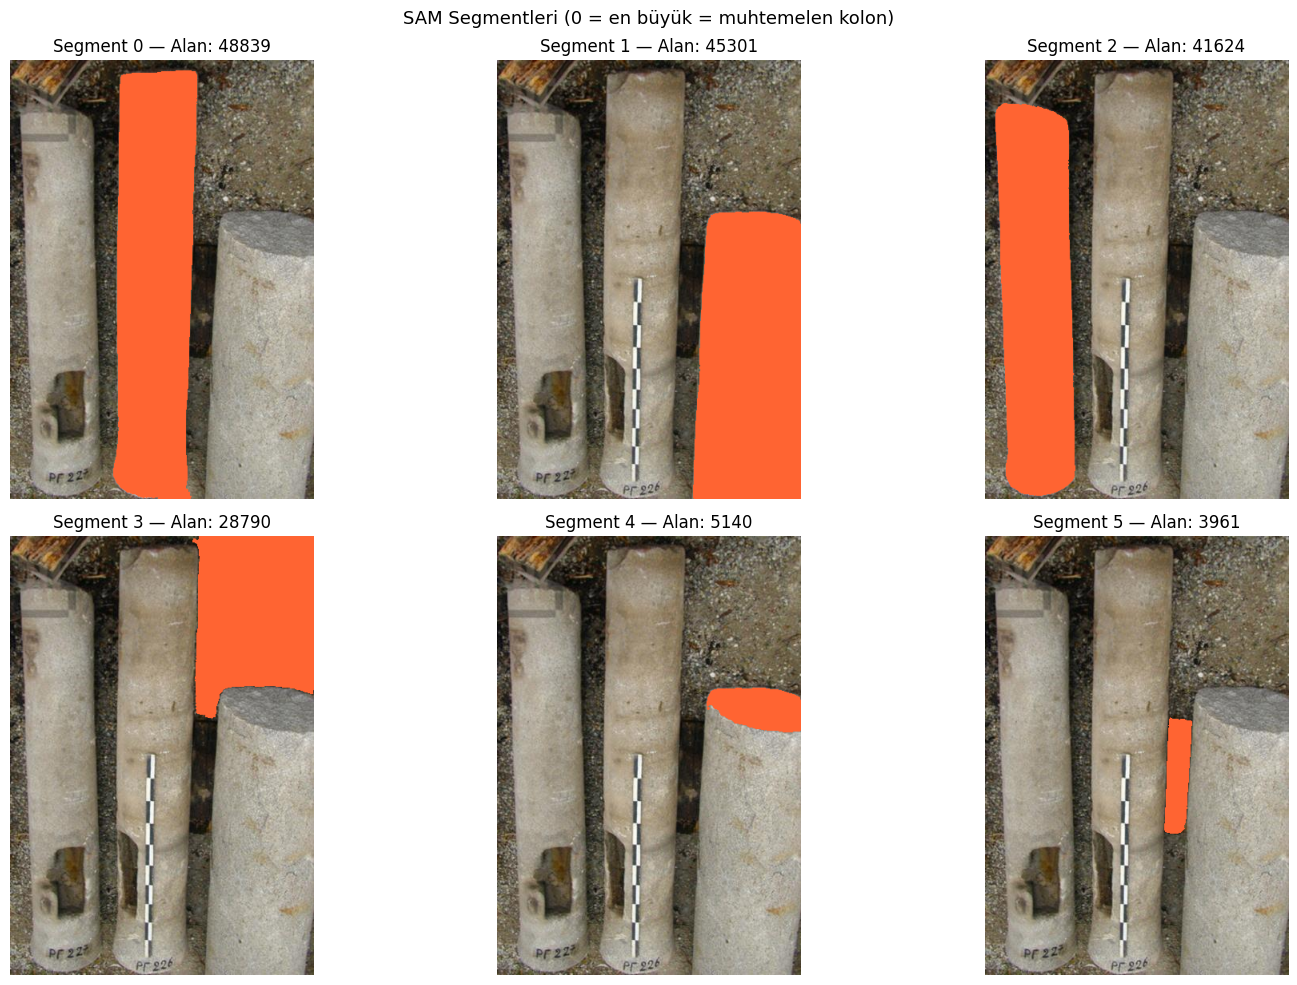

In [8]:
def visualize_all_segments(img_bgr, masks, top_n=6):
    """
    SAM'ın bulduğu ilk N segmenti göster.
    Hangisinin kolon olduğunu doğrula.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    masks_sorted = sorted(masks, key=lambda m: m['area'], reverse=True)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for i, ax in enumerate(axes.flat):
        if i >= len(masks_sorted):
            ax.axis('off')
            continue
        overlay = img_rgb.copy()
        seg = masks_sorted[i]['segmentation']
        overlay[seg] = [255, 100, 50]   # turuncu overlay
        ax.imshow(overlay)
        ax.set_title(f"Segment {i} — Alan: {masks_sorted[i]['area']}")
        ax.axis('off')
    plt.suptitle("SAM Segmentleri (0 = en büyük = muhtemelen kolon)", fontsize=13)
    plt.tight_layout()
    plt.show()

# Test görüntüsü seç
damaged_files = [f for f in os.listdir(DAMAGED_DIR)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]

test_path = os.path.join(DAMAGED_DIR, damaged_files[0])
img = cv2.imread(test_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# SAM çalıştır
masks = mask_generator.generate(img_rgb)
print(f"Bulunan segment sayısı: {len(masks)}")

visualize_all_segments(img, masks)

In [ ]:
!pip install simple-lama-inpainting -q

from simple_lama_inpainting import SimpleLama
from PIL import Image

lama = SimpleLama()

# Preprocess buraya ekle
def preprocess(img):
    denoised = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab = cv2.merge([clahe.apply(l), a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def full_pipeline_sam(img_path):
    img = cv2.imread(img_path)
    fname = os.path.basename(img_path)

    proc = preprocess(img)
    img_rgb = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)

    masks = mask_generator.generate(img_rgb)
    masks_sorted = sorted(masks, key=lambda m: m['area'], reverse=True)
    column_mask = masks_sorted[0]['segmentation'].astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    column_filled = cv2.morphologyEx(column_mask, cv2.MORPH_CLOSE, kernel, iterations=4)
    damage_mask   = cv2.bitwise_and(column_filled, cv2.bitwise_not(column_mask))
    damage_mask   = cv2.morphologyEx(damage_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    img_pil  = Image.fromarray(img_rgb)
    mask_pil = Image.fromarray(damage_mask)
    restored = lama(img_pil, mask_pil)

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Orijinal')
    axes[1].imshow(column_mask, cmap='gray');              axes[1].set_title('Kolon Maskesi (SAM)')
    axes[2].imshow(damage_mask, cmap='gray');              axes[2].set_title('Hasar Maskesi')
    axes[3].imshow(np.array(restored));                    axes[3].set_title('Restore (LaMa)')
    for ax in axes: ax.axis('off')
    plt.suptitle(fname, fontsize=11)
    plt.tight_layout()
    plt.show()

    return restored, damage_mask

restored, mask = full_pipeline_sam(test_path)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
scikit-

Downloading: "https://github.com/enesmsahin/simple-lama-inpainting/releases/download/v0.1.0/big-lama.pt" to /root/.cache/torch/hub/checkpoints/big-lama.pt
100%|██████████| 196M/196M [00:00<00:00, 314MB/s]


In [9]:
# Gerçek hasarlı ve pipeline için uygun olanlar
good_indices = [2, 3, 6, 9, 12, 14, 15, 17, 19, 20, 21, 25, 26, 27, 29]

good_files = [damaged_files[i] for i in good_indices if i < len(damaged_files)]
print(f"Seçilen: {len(good_files)} görüntü")
for i, f in zip(good_indices, good_files):
    print(f"  [{i}] {f}")

Seçilen: 15 görüntü
  [2] 3caca242a1e3dfe5699a5bd543fdf220.jpg
  [3] d3f6938257c937fe01294087b121918b.jpg
  [6] 35fb0ce076ee34a34e0db00b1f9c4851.jpg
  [9] d66ff091604421e5e9aa51613fb4a6cf.jpg
  [12] Roman_column_of_the_santuari_3_d'Almallutx_01.jpg
  [14] Ancient_Roman_Column_in_the_Gardens_of_Puerta_Oscura.jpg
  [15] Remain_of_Roman_column_in_the_Basailic_of_San_Paolo.jpg
  [17] Remains_of_an_Ionic_column_at_the_Roman_Agora_of_Athens_on_March_7,_2022.jpg
  [19] Roman_column_of_the_santuari_3_d'Almallutx_02.jpg
  [20] Ancient_Roman_domus_(Tyndaris)_01.jpg
  [21] Part_of_Roman_Column (1).jpg
  [25] a9ca5f5b6ba9cd36e161e86f0fa4925b.jpg
  [26] 9efb7af1ba042699fcc8806e15e6fc31.jpg
  [27] bdf74ec3cfad78d67b97a127b0677dd8.jpg
  [29] 0.jpg


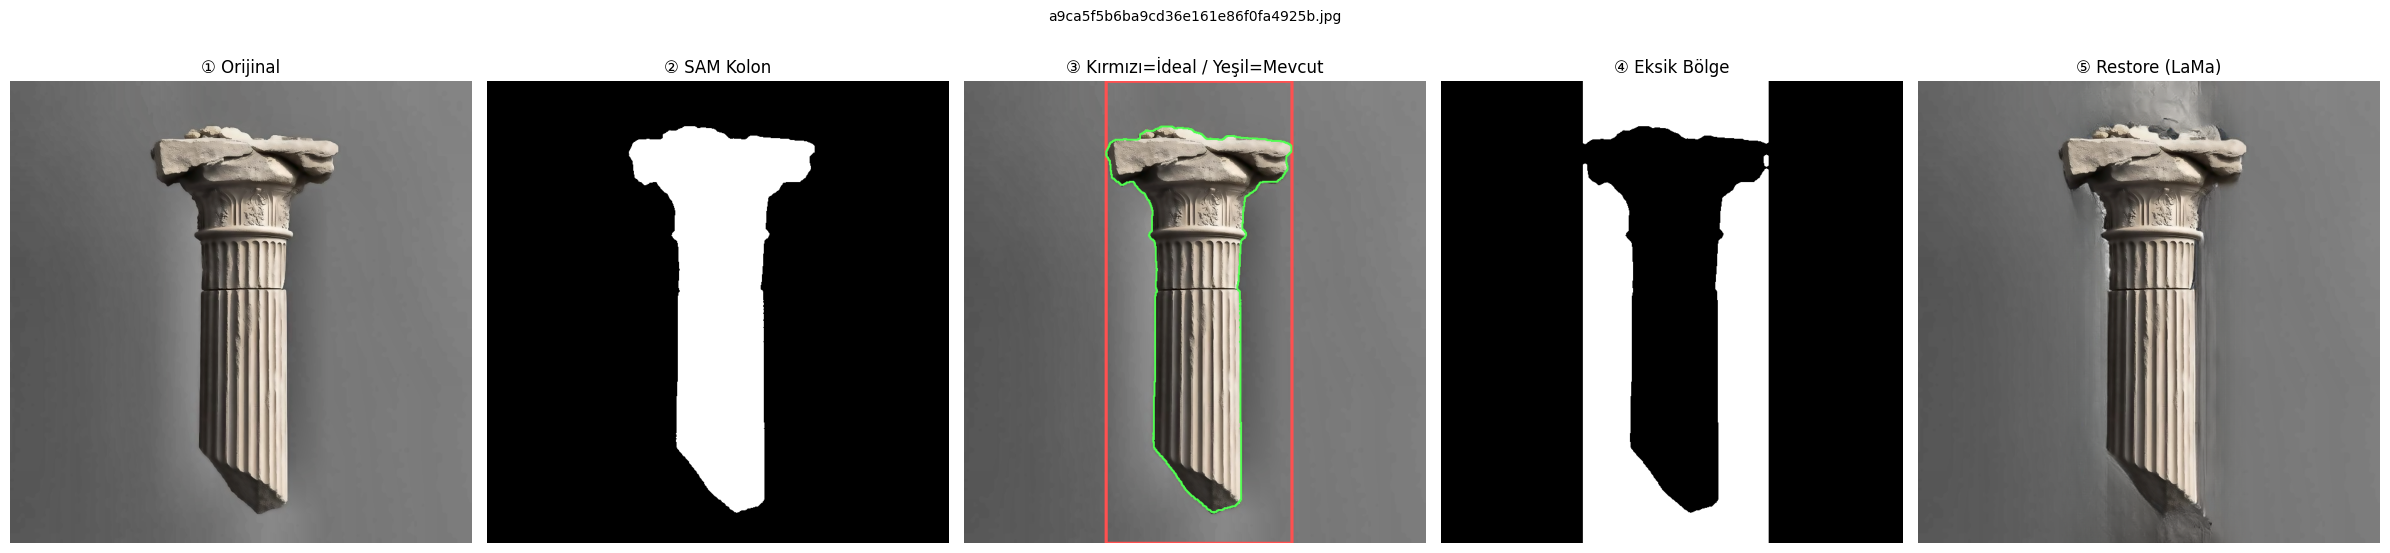

In [12]:
def select_column_mask(masks_sorted, img_shape):
    """
    En büyük alan yerine en yüksek en/boy oranına sahip segmenti seç.
    Kolon = dar ve uzun (aspect ratio yüksek)
    """
    h_img, w_img = img_shape[:2]
    best_mask  = None
    best_score = 0

    for m in masks_sorted[:8]:  # ilk 8 adaya bak
        seg = m['segmentation'].astype(np.uint8) * 255
        cnts, _ = cv2.findContours(seg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        cnt = max(cnts, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)

        aspect_ratio = h / (w + 1e-5)   # yüksek = kolon
        area_ratio   = m['area'] / (h_img * w_img)  # görüntünün ne kadarı

        # Kolon: aspect ratio > 1.5, alanın %5-60'ı arasında
        if aspect_ratio > 1.5 and 0.05 < area_ratio < 0.60:
            score = aspect_ratio * area_ratio
            if score > best_score:
                best_score = score
                best_mask  = m

    # Uygun bulunamazsa en büyüğe dön
    return best_mask if best_mask else masks_sorted[0]


def create_missing_part_mask_v3(img_bgr, masks_sorted, expand_ratio=0.15):
    h_img, w_img = img_bgr.shape[:2]

    # Kolon maskesini akıllıca seç
    best = select_column_mask(masks_sorted, img_bgr.shape)
    column_seg = best['segmentation'].astype(np.uint8) * 255

    cnts, _ = cv2.findContours(column_seg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None, None, None
    main_cnt = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(main_cnt)

    expand_h = int(h * expand_ratio)
    ideal_mask = np.zeros((h_img, w_img), dtype=np.uint8)
    y_top    = max(0, y - expand_h)
    y_bottom = min(h_img, y + h + expand_h)
    ideal_mask[y_top:y_bottom, x:x+w] = 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    column_filled = cv2.morphologyEx(column_seg, cv2.MORPH_CLOSE, kernel, iterations=3)
    missing_mask  = cv2.bitwise_and(ideal_mask, cv2.bitwise_not(column_filled))
    missing_mask  = cv2.morphologyEx(missing_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return column_seg, missing_mask, (x, y_top, w, y_bottom - y_top)

def full_pipeline_v3(img_path, expand_ratio=0.15):
    img   = cv2.imread(img_path)
    fname = os.path.basename(img_path)
    proc  = preprocess(img)
    img_rgb = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)

    masks = mask_generator.generate(img_rgb)
    if not masks:
        print(f"SAM maske bulamadı: {fname}")
        return None, None
    masks_sorted = sorted(masks, key=lambda m: m['area'], reverse=True)

    result = create_missing_part_mask_v3(proc, masks_sorted, expand_ratio)
    if result[0] is None:
        print(f"Kolon bulunamadı: {fname}")
        return None, None

    column_mask, missing_mask, bbox = result

    if np.sum(missing_mask) < 500:
        print(f"Eksik bölge çok küçük, atlanıyor: {fname}")
        return None, None

    # İdeal form görseli
    x, y, w, h = bbox
    ideal_vis = img_rgb.copy()
    cv2.rectangle(ideal_vis, (x, y), (x+w, y+h), (255, 80, 80), 3)  # kırmızı = ideal
    cnts, _ = cv2.findContours(column_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        cv2.drawContours(ideal_vis, [max(cnts, key=cv2.contourArea)], -1, (80,255,80), 2)  # yeşil = mevcut

    # LaMa
    img_pil  = Image.fromarray(img_rgb)
    mask_pil = Image.fromarray(missing_mask)
    restored = lama(img_pil, mask_pil)

    fig, axes = plt.subplots(1, 5, figsize=(24, 6))
    axes[0].imshow(img_rgb);                   axes[0].set_title('① Orijinal')
    axes[1].imshow(column_mask, cmap='gray');  axes[1].set_title('② SAM Kolon')
    axes[2].imshow(ideal_vis);                 axes[2].set_title('③ Kırmızı=İdeal / Yeşil=Mevcut')
    axes[3].imshow(missing_mask, cmap='gray'); axes[3].set_title('④ Eksik Bölge')
    axes[4].imshow(np.array(restored));        axes[4].set_title('⑤ Restore (LaMa)')
    for ax in axes: ax.axis('off')
    plt.suptitle(fname, fontsize=10)
    plt.tight_layout()
    plt.show()

    return restored, missing_mask

# Önce tek test — [2] indeksi iyi bir aday
test_path_25 = os.path.join(DAMAGED_DIR, damaged_files[25])
restored, mask = full_pipeline_v3(test_path_25, expand_ratio=0.20)

In [ ]:
def load_reference_textures(reference_dir, n=10):
    """Referans kolonlardan doku örnekleri topla"""
    ref_files = [f for f in os.listdir(reference_dir)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
    textures = []
    for fname in ref_files[:n]:
        path = os.path.join(reference_dir, fname)
        img  = cv2.imread(path)
        if img is not None:
            img = preprocess(img)
            textures.append(img)
    print(f"{len(textures)} referans doku yüklendi.")
    return textures

def get_reference_texture_patch(textures, target_shape):
    """
    Referans kolonlardan hedef bölgeyle aynı boyutta
    ortalama doku üret
    """
    h, w = target_shape[:2]
    patches = []
    for tex in textures:
        th, tw = tex.shape[:2]
        # Referanstan rastgele bir bölge kes
        if th >= h and tw >= w:
            y0 = np.random.randint(0, th - h + 1)
            x0 = np.random.randint(0, tw - w + 1)
            patch = tex[y0:y0+h, x0:x0+w]
            patches.append(patch.astype(np.float32))
    if not patches:
        return None
    return np.mean(patches, axis=0).astype(np.uint8)

def symmetry_restore(img_bgr, column_mask):
    """
    1. Simetri eksenini bul (kolonun dikey merkezi)
    2. Daha sağlam tarafı belirle (daha fazla beyaz piksel)
    3. Sağlam tarafı aynalayarak eksik tarafı doldur
    """
    h, w = img_bgr.shape[:2]

    cnts, _ = cv2.findContours(column_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return img_bgr.copy(), None
    main_cnt = max(cnts, key=cv2.contourArea)
    x, y, col_w, col_h = cv2.boundingRect(main_cnt)
    cx = x + col_w // 2  # simetri ekseni

    # Sol ve sağ yarıdaki kolon piksel sayısı
    left_pixels  = np.sum(column_mask[:, x:cx] > 128)
    right_pixels = np.sum(column_mask[:, cx:x+col_w] > 128)

    result = img_bgr.copy()

    if left_pixels >= right_pixels:
        # Sol taraf daha sağlam → sağa aynala
        good_side   = img_bgr[:, x:cx]
        mirror      = cv2.flip(good_side, 1)
        mirror_w    = mirror.shape[1]
        fill_region = result[:, cx:cx+mirror_w]
        # Sadece kolon maskesi içine uygula
        col_mask_region = column_mask[:, cx:cx+mirror_w]
        fill_region[col_mask_region > 128] = mirror[col_mask_region > 128]
        result[:, cx:cx+mirror_w] = fill_region
        damaged_side = 'sağ'
    else:
        # Sağ taraf daha sağlam → sola aynala
        good_side   = img_bgr[:, cx:x+col_w]
        mirror      = cv2.flip(good_side, 1)
        mirror_w    = mirror.shape[1]
        x_start     = max(0, cx - mirror_w)
        fill_region = result[:, x_start:cx]
        col_mask_region = column_mask[:, x_start:cx]
        fill_region[col_mask_region > 128] = mirror[col_mask_region > 128]
        result[:, x_start:cx] = fill_region
        damaged_side = 'sol'

    print(f"  Simetri: {damaged_side} taraf tamamlandı (sol={left_pixels}px, sağ={right_pixels}px)")
    return result, cx

def full_pipeline_symmetry(img_path, textures, expand_ratio=0.20):
    img   = cv2.imread(img_path)
    fname = os.path.basename(img_path)
    proc  = preprocess(img)
    img_rgb = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)

    print(f"\nİşleniyor: {fname}")

    # 1. SAM segmentasyon
    masks = mask_generator.generate(img_rgb)
    if not masks:
        print("  SAM maske bulamadı.")
        return None
    masks_sorted = sorted(masks, key=lambda m: m['area'], reverse=True)

    # 2. Kolon maskesi
    result = create_missing_part_mask_v3(proc, masks_sorted, expand_ratio)
    if result[0] is None:
        print("  Kolon bulunamadı.")
        return None
    column_mask, missing_mask, bbox = result
    x, y_top, w, h = bbox

    # 3. Simetri ile tamamla
    print("  Adım 1: Simetri uygulanıyor...")
    sym_result_bgr, sym_axis = symmetry_restore(proc, column_mask)
    sym_result_rgb = cv2.cvtColor(sym_result_bgr, cv2.COLOR_BGR2RGB)

    # 4. Simetri sonrası kalan boşlukları bul
    #    Referans doku ile ön dolgu yap
    print("  Adım 2: Referans doku entegrasyonu...")
    if textures and np.sum(missing_mask) > 500:
        ref_patch = get_reference_texture_patch(textures, proc.shape)
        if ref_patch is not None:
            ref_rgb = cv2.cvtColor(ref_patch, cv2.COLOR_BGR2RGB)
            # Sadece eksik maske bölgesine referans dokuyu karıştır (%30)
            sym_result_rgb_float = sym_result_rgb.astype(np.float32)
            ref_rgb_float        = ref_rgb.astype(np.float32)
            mask_3ch = np.stack([missing_mask/255]*3, axis=-1)
            blended  = sym_result_rgb_float * (1 - 0.3*mask_3ch) + ref_rgb_float * 0.3*mask_3ch
            sym_result_rgb = np.clip(blended, 0, 255).astype(np.uint8)

    # 5. LaMa ile final pürüzsüzleştirme
    print("  Adım 3: LaMa final dokunuşu...")
    if np.sum(missing_mask) > 500:
        img_pil  = Image.fromarray(sym_result_rgb)
        mask_pil = Image.fromarray(missing_mask)
        restored = lama(img_pil, mask_pil)
        final    = np.array(restored)
    else:
        final = sym_result_rgb
        print("  (Eksik bölge küçük, LaMa atlandı)")

    # 6. Görselleştirme
    sym_axis_vis = img_rgb.copy()
    if sym_axis:
        cv2.line(sym_axis_vis, (sym_axis, 0), (sym_axis, img_rgb.shape[0]), (255,50,50), 2)
    cnts, _ = cv2.findContours(column_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        cv2.drawContours(sym_axis_vis, [max(cnts, key=cv2.contourArea)], -1, (50,255,50), 2)

    fig, axes = plt.subplots(1, 5, figsize=(26, 7))
    axes[0].imshow(img_rgb);            axes[0].set_title('① Orijinal')
    axes[1].imshow(sym_axis_vis);       axes[1].set_title('② SAM + Simetri Ekseni')
    axes[2].imshow(sym_result_rgb);     axes[2].set_title('③ Simetri Sonrası')
    axes[3].imshow(missing_mask, cmap='gray'); axes[3].set_title('④ Kalan Eksik Bölge')
    axes[4].imshow(final);              axes[4].set_title('⑤ Final (Ref + LaMa)')
    for ax in axes: ax.axis('off')
    plt.suptitle(fname, fontsize=10)
    plt.tight_layout()
    plt.show()

    return final

# Referansları yükle
textures = load_reference_textures(REFERENCE_DIR, n=10)

# [25] ile test
test_path_25 = os.path.join(DAMAGED_DIR, damaged_files[25])
result = full_pipeline_symmetry(test_path_25, textures, expand_ratio=0.20)